Zaarane Ilyès 12406573 TP GOUPE 8

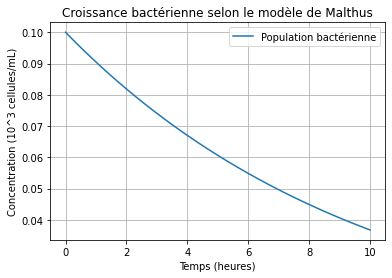

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Paramètres de la simulation
rmax = -0.1  # taux de croissance maximal (h⁻¹)
C0 = 0.1  # Concentration des cellules bactériennes au début de la simulation (10^3 cellules.mL-1)
T = 10 # durée totale de la simulation (heures)
dt = 0.1 # pas de temps (heures)
N_steps = int(T / dt)

# Simulation
time = np.linspace(0, T, N_steps)
C = C0 * np.exp(rmax * time)

# Tracé du graphique
plt.title('Croissance bactérienne selon le modèle de Malthus')  # Titre du graphique
plt.plot(time, C, label='Population bactérienne') # Nom de la courbe
plt.xlabel('Temps (heures)') # Axe des X
plt.ylabel('Concentration (10^3 cellules/mL)') # Axe des Y
plt.grid(True)
plt.legend()
plt.show()

Question 1:
Ce type de courbe s’appelle une courbe exponentielle ou courbe de croissance exponentielle. Elle montre une augmentation rapide de la population avec le temps.

Question 2:
Le temps de doublement Tdouble est donné par la formule :
Tdouble = ln(2) / rmax
Par exemple, si rmax = 0.2 par heure, alors :
Tdouble = 0.693 / 0.2 = 3.47 heures.
Donc, la population double environ toutes les 3,5 heures dans cet exemple.

Question 3:
Avec rmax=0.4, la croissance est plus rapide, la population double en environ 1,7 heures
Avec rmax=0.1, la croissance est plus lente, le doublement prend environ 6,9 heures
Avec rmax=0, la population reste constante, il n’y a ni croissance ni décroissance
Avec rmax=-0.1, la population diminue, elle décroît avec le temps
Conclusion : La vitesse de croissance dépend de rmax. Si rmax est positif, la population croît rapidement. Si rmax est zéro, la population reste stable. Si rmax est négatif, la population diminue.

Question 4:
Quand rmax=0, la population ne change pas. Elle reste constante
Quand rmax est négatif, la population diminue rapidement

Question 5:
Limites :
Il suppose que la croissance peut continuer indéfiniment, ce qui n’est pas vrai en réalité car il y a des ressources limitées
Il ne prend pas en compte la compétition entre individus ou la saturation du milieu
Il ne modélise pas la mortalité ou d’autres facteurs environnementaux
Améliorations possibles :
Ajouter une limite de capacité (modèle logistique)
Inclure un terme de mortalité
Modéliser la consommation de ressources, par exemple avec le modèle de Monod
Intégrer des facteurs environnementaux ou évolutifs


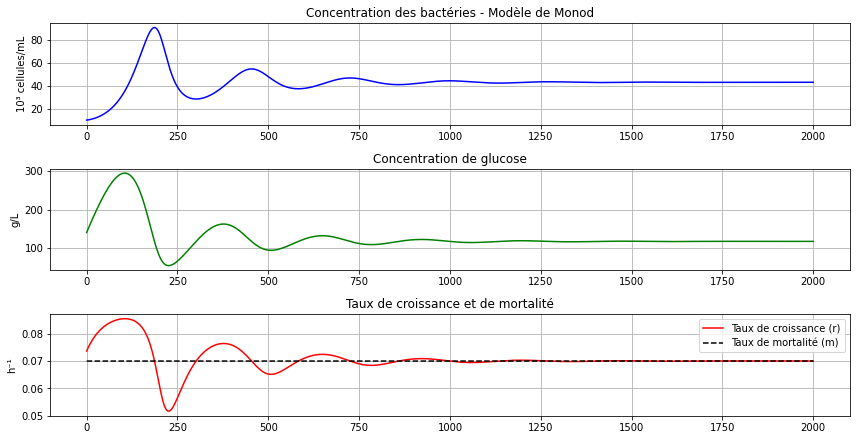

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ======================
# PARAMÈTRES DE LA SIMULATION
# ======================
T = 2000          # Durée totale (heures)
dt = 0.1          # Pas de temps (heures)
N_steps = int(T / dt)  # Nombre de pas de temps

# ======================
# PARAMÈTRES DE LA SOUCHE
# ======================
rmax = 0.10       # Taux de croissance maximal (h⁻¹)
K = 50           # Affinité pour le substrat (g/L)
m0 = 0.07         # Taux de mortalité minimal (h⁻¹)
C0 = 10 # Concentration initiale de bactéries (10³ cellules/mL)

# ======================
# PARAMÈTRES DU SUBSTRAT (GLUCOSE)
# ======================
initial_glucose = 140  # Concentration initiale de glucose (g/L)
glucose_inflow = 3      # Flux entrant de glucose (g/L/h)

# ======================
# INITIALISATION DES TABLEAUX
# ======================
C = np.zeros(N_steps)          # Concentration bactérienne
glucose_level = np.zeros(N_steps)
growth_rate = np.zeros(N_steps)
mortality_rate = np.zeros(N_steps)

# ======================
# CONDITIONS INITIALES
# ======================
C[0] = C0
glucose_level[0] = initial_glucose
growth_rate[0] = rmax * glucose_level[0] / (K + glucose_level[0])
mortality_rate[0] = m0

# ======================
# SIMULATION
# ======================
for i in range(1, N_steps):
    # Calcul des taux
    r = rmax * glucose_level[i-1] / (K + glucose_level[i-1])

    # Mise à jour de la population bactérienne
    C[i] = C[i-1] + dt * (r - m0) * C[i-1]

    # Mise à jour du glucose (consommation + flux entrant)
    glucose_level[i] = glucose_level[i-1] - dt * r * C[i-1] + glucose_inflow * dt

    # Stockage des taux
    growth_rate[i] = r
    mortality_rate[i] = m0

# ======================
# AXE DES X EN HEURES
# ======================
time = np.linspace(0, T, N_steps)

# ======================
# TRACÉ DES COURBES
# ======================
plt.figure(figsize=(12, 8))

# 1. Concentration bactérienne
plt.subplot(4, 1, 1)
plt.plot(time, C, label='Nombre de bactéries', color='blue')
plt.title('Concentration des bactéries - Modèle de Monod')
plt.ylabel('10³ cellules/mL')
plt.grid(True)

# 2. Concentration de glucose
plt.subplot(4, 1, 2)
plt.plot(time, glucose_level, label='Concentration de glucose', color='green')
plt.title('Concentration de glucose')
plt.ylabel('g/L')
plt.grid(True)

# 3. Taux de croissance ET mortalité (sur le même graphique)
plt.subplot(4, 1, 3)
plt.plot(time, growth_rate, label='Taux de croissance (r)', color='red')
plt.plot(time, mortality_rate, label='Taux de mortalité (m)', color='black', linestyle='--')  # Ligne noire en pointillé
plt.title('Taux de croissance et de mortalité')
plt.ylabel('h⁻¹')
plt.legend()  # Affiche la légende pour les deux courbes
plt.grid(True)

plt.tight_layout()
plt.show()

Question 1 :
La concentration de bactéries augmente rapidement au début car le glucose est abondant. Elle atteint ensuite un maximum, puis diminue quand le glucose devient rare.
La concentration de glucose diminue progressivement car elle est consommée par les bactéries.
Le taux de croissance r est élevé au début, puis baisse avec l’épuisement du glucose.
Le taux de mortalité m reste constant. Quand r > m, la population augmente ; quand r < m, elle diminue.

Question 2 :
Le facteur limitant est le substrat, c’est-à-dire la concentration de glucose disponible. La croissance dépend directement de la disponibilité du glucose selon le modèle de Monod.  

Question 3 :
La population décroît lorsque le taux de croissance devient inférieur au taux de mortalité :
r < m.
Si r = m, la population reste stable.
Si r > m, la population augmente.

Question 4 :
Quand on augmente rmax, les bactéries se développent plus vite et le glucose est consommé plus rapidement.
Quand on augmente m0, la mortalité augmente et la population diminue plus vite.
Quand on augmente K, les bactéries ont une moins bonne affinité pour le glucose, donc leur croissance est moins efficace surtout quand le glucose devient faible.

Question 5 :
Pour que la population se maintienne dans le temps, il faut un apport régulier de glucose, donc un glucose_inflow. Il faut que le glucose apporté permette de garder un taux de croissance proche ou supérieur au taux de mortalité, donc r ≥ m.

Question 6 :
La population bactérienne augmente fortement au début, puis elle chute, puis remonte plusieurs fois. Après ces oscillations, elle finit par se stabiliser.
Le glucose varie aussi : il augmente grâce au flux entrant, puis baisse quand les bactéries le consomment.
Le taux de croissance r oscille autour du taux de mortalité m, puis se stabilise presque au même niveau.

Question 7 :
Les fluctuations sont dues au décalage entre l’apport de glucose et la consommation par les bactéries.
Quand il y a beaucoup de glucose, les bactéries se multiplient vite. Elles deviennent trop nombreuses et consomment beaucoup de glucose, donc le glucose diminue. Ensuite, la croissance baisse, la population diminue, puis le glucose remonte grâce au flux entrant. Ce cycle se répète avant l’équilibre.

Question 8 :
Avec un flux entrant constant de glucose, la population ne disparaît pas. Elle atteint un équilibre car l’apport de glucose compense progressivement la consommation des bactéries et la mortalité.
Donc le maintien de la population dépend d’un équilibre entre glucose disponible, croissance bactérienne et mortalité.

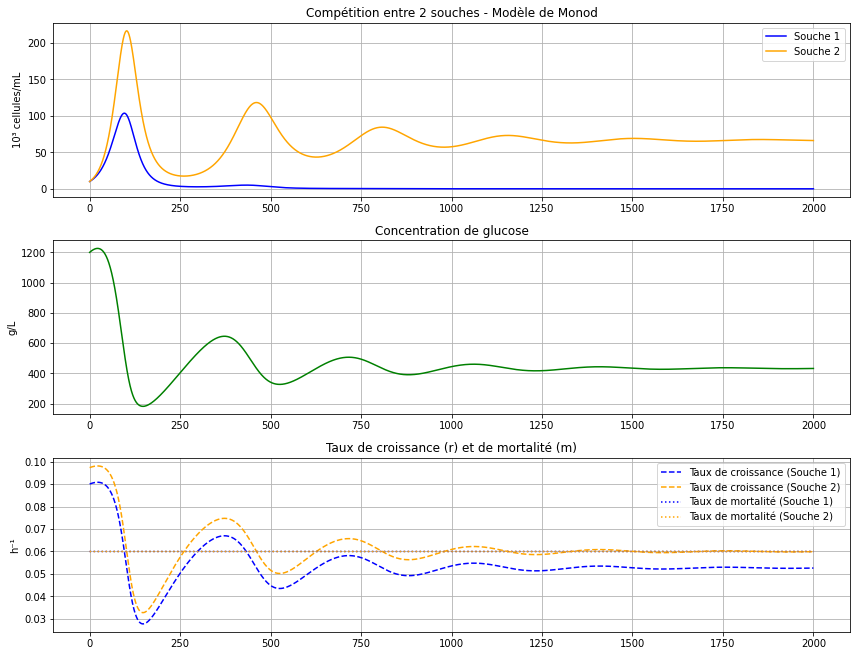

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# =============================================
# Paramètres pour la souche 1
# =============================================
rmax_1 = 0.15      # Taux de croissance maximal (souche 1)
m0_1 = 0.06      # Taux de mortalité de base (souche 1)
K_1 = 800        # Constante de demi-saturation (souche 1)

# =============================================
# Paramètres pour la souche 2
# =============================================
rmax_2 = 0.15      # Taux de croissance maximal (souche 2)
m0_2 = 0.06      # Taux de mortalité de base (souche 2)
K_2 = 650      # Constante de demi-saturation (souche 2) - affinité plus élevée pour le glucose

# =============================================
# Paramètres du glucose
# =============================================
initial_glucose = 1200   # Quantité initiale de glucose
glucose_inflow = 4      # Flux entrant de glucose (0 = système fermé)

# =============================================
# Conditions initiales
# =============================================
C0_1 = 10  # Concentration initiale de la souche 1
C0_2 = 10   # Concentration initiale de la souche 2

# =============================================
# Paramètres de la simulation
# =============================================
dt = 0.1         # Pas de temps
T = 2000         # Durée totale de la simulation
N_steps = int(T / dt)# Nombre de pas de temps

# =============================================
# Initialisation des tableaux
# =============================================
C1 = np.zeros(N_steps)
C2 = np.zeros(N_steps)
glucose_level = np.zeros(N_steps)
growth_rate_1 = np.zeros(N_steps)
growth_rate_2 = np.zeros(N_steps)
mortality_rate_1 = np.zeros(N_steps)
mortality_rate_2 = np.zeros(N_steps)

# Conditions initiales
C1[0] = C0_1
C2[0] = C0_2
glucose_level[0] = initial_glucose
growth_rate_1[0] = rmax_1 * glucose_level[0] / (K_1 + glucose_level[0])
growth_rate_2[0] = rmax_2 * glucose_level[0] / (K_2 + glucose_level[0])
mortality_rate_1[0] = m0_1
mortality_rate_2[0] = m0_2

# =============================================
# Simulation
# =============================================
for i in range(1, N_steps):
    # Calcul des taux de croissance pour chaque souche (modèle de Monod)
    r_1 = rmax_1 * glucose_level[i-1] / (K_1 + glucose_level[i-1])
    r_2 = rmax_2 * glucose_level[i-1] / (K_2 + glucose_level[i-1])

    # Mortalité variable (augmente si le glucose est faible)
    #m_1 = m0_1 + 0.01 * (1 - glucose_level[i-1] / initial_glucose)
    #m_2 = m0_2 + 0.01 * (1 - glucose_level[i-1] / initial_glucose)

      # Mortalité constante
    m_1 = m0_1 
    m_2 = m0_2
    
    # Mise à jour des populations bactériennes
    C1[i] = C1[i-1] + dt * (r_1 - m_1) * C1[i-1]
    C2[i] = C2[i-1] + dt * (r_2 - m_2) * C2[i-1]

    # Consommation totale de glucose (somme des consommations des deux souches)
    glucose_consumption = (r_1 * C1[i-1] + r_2 * C2[i-1])
    glucose_level[i] = glucose_level[i-1] - dt * glucose_consumption + glucose_inflow * dt

    # Stockage des taux
    growth_rate_1[i] = r_1
    growth_rate_2[i] = r_2
    mortality_rate_1[i] = m_1
    mortality_rate_2[i] = m_2

# =============================================
# Temps pour l'axe des abscisses
# =============================================
time = np.linspace(0, T, N_steps)

# =============================================
# Tracé des courbes
# =============================================
plt.figure(figsize=(12, 12))

# Population des bactéries
plt.subplot(4, 1, 1)
plt.plot(time, C1, label='Souche 1', color='blue')
plt.plot(time, C2, label='Souche 2', color='orange')
plt.title('Compétition entre 2 souches - Modèle de Monod')
plt.ylabel('10³ cellules/mL')
plt.legend()
plt.grid(True)

# Niveau de glucose
plt.subplot(4, 1, 2)
plt.plot(time, glucose_level, label='Glucose', color='green')
plt.title('Concentration de glucose')
plt.ylabel('g/L')
plt.grid(True)

# Taux de croissance et mortalité
plt.subplot(4, 1, 3)
plt.plot(time, growth_rate_1, label='Taux de croissance (Souche 1)', color='blue', linestyle='--')
plt.plot(time, growth_rate_2, label='Taux de croissance (Souche 2)', color='orange', linestyle='--')
plt.plot(time, mortality_rate_1, label='Taux de mortalité (Souche 1)', color='blue', linestyle=':')
plt.plot(time, mortality_rate_2, label='Taux de mortalité (Souche 2)', color='orange', linestyle=':')
plt.title('Taux de croissance (r) et de mortalité (m)')
plt.ylabel('h⁻¹')
plt.legend()
plt.grid(True)

# Taux de mortalité
#plt.subplot(4, 1, 4)
#plt.plot(time, mortality_rate_1, label='Taux de mortalité (Souche 1)', color='blue', linestyle=':')
#plt.plot(time, mortality_rate_2, label='Taux de mortalité (Souche 2)', color='orange', linestyle=':')
#plt.title('Taux de mortalité (m) au fil du temps')
#plt.xlabel('Temps')
#plt.ylabel('Taux de mortalité (m)')
#plt.legend()
#plt.grid(True)

plt.tight_layout()
plt.show()

Question 1 :
Les deux souches augmentent au début car le glucose est abondant. La souche 2 augmente plus vite et atteint un pic plus élevé que la souche 1. Ensuite, les deux populations diminuent quand le glucose baisse, puis la souche 2 remonte et se stabilise, alors que la souche 1 reste très faible.

Question 2 :
La concurrence favorise la souche 2. Elle utilise mieux le glucose car son K est plus faible, donc elle a une meilleure affinité pour le substrat. La souche 1 est progressivement éliminée ou devient presque nulle.

Question 3 :
La souche 1 l’emporte si on diminue son taux de mortalité m. À partir du moment où sa mortalité devient assez faible pour compenser sa moins bonne affinité au glucose, elle peut dépasser la souche 2. Donc elle l’emporte quand m1 est inférieur à m2 de façon suffisante.

Question 4 :
Les graphiques montrent que la sélection naturelle favorise la souche la mieux adaptée au milieu. Ici, la souche 2 est avantagée car elle exploite mieux le glucose. Avec le temps, elle devient majoritaire tandis que la souche 1 disparaît presque.

Question 5 :
Pour que les deux souches coexistent, il faut que leurs avantages et désavantages s’équilibrent. Par exemple, une souche peut avoir une meilleure affinité pour le glucose, mais aussi une mortalité plus élevée ou un taux de croissance maximal plus faible. Il faut donc que leurs croissances nettes soient proches : r1 - m1 ≈ r2 - m2.

Question 6 :
Si on augmente rmax, la souche se multiplie plus vite et peut prendre l’avantage.
Si on diminue K, la souche a une meilleure affinité pour le glucose et peut croître même quand le glucose est faible.
Si on augmente K, la souche devient moins compétitive car elle a besoin de plus de glucose pour croître efficacement.

Question 7 :
Pour ajouter une troisième souche, il faut créer de nouveaux paramètres : rmax_3, m0_3, K_3, C0_3, puis ajouter une courbe C3 dans la simulation.
La troisième souche entrera aussi en compétition pour le même glucose, et son devenir dépendra de ses paramètres. La souche qui aura le meilleur équilibre entre croissance, affinité au glucose et mortalité deviendra majoritaire.

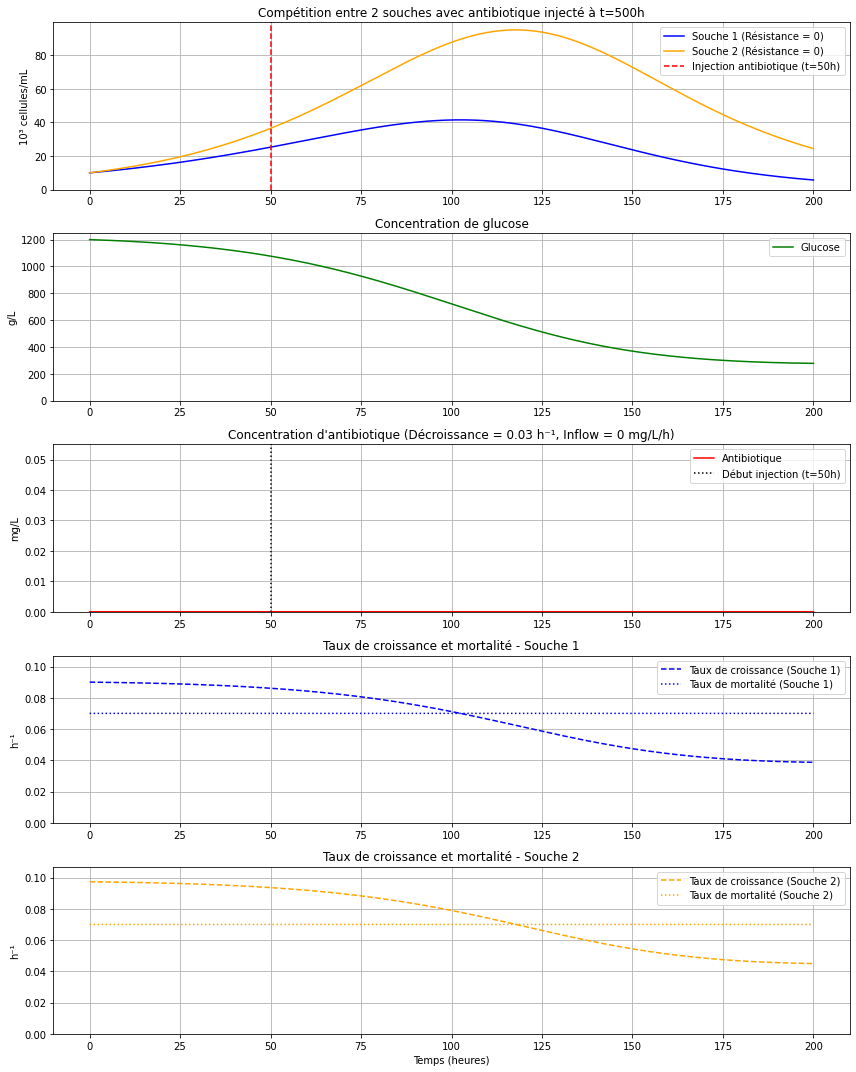

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# =============================================
# PARAMÈTRES POUR LES SOUCHES
# =============================================
# Souche 1
rmax_1 = 0.15      # Taux de croissance maximal (h⁻¹)
m0_1 = 0.07        # Taux de mortalité de base (h⁻¹)
K_1 = 800              # Constante de demi-saturation (g/L)
resistance_1 = 0  # Résistance à l'antibiotique (0 = aucune, 1 = totale)

# Souche 2
rmax_2 = 0.15      # Taux de croissance maximal (h⁻¹)
m0_2 = 0.07        # Taux de mortalité de base (h⁻¹)
K_2 = 650          # Constante de demi-saturation (g/L)
resistance_2 = 0 # Résistance à l'antibiotique

# =============================================
# PARAMÈTRES DU GLUCOSE
# =============================================
initial_glucose = 1200   # Concentration initiale de glucose (g/L)
glucose_inflow = 1      # Flux entrant de glucose (g/L/h)

# =============================================
# PARAMÈTRES DE L'ANTIBIOTIQUE
# =============================================
initial_antibiotic = 0   # Concentration initiale d'antibiotique (mg/L)
antibiotic_intensity = 3 # Intensité (0 = aucun effet, 1 = mortalité doublée)
antibiotic_decay = 0.03    # Taux de décroissance naturelle (h⁻¹)
antibiotic_inflow = 0      # Flux entrant d'antibiotique (mg/L/h)
antibiotic_start_time = 50  # Temps (en heures) avant l'injection

# =============================================
# CONDITIONS INITIALES
# =============================================
C0_1 = 10  # Concentration initiale de la souche 1 (10³ cellules/mL)
C0_2 = 10  # Concentration initiale de la souche 2 (10³ cellules/mL)

# =============================================
# PARAMÈTRES DE LA SIMULATION
# =============================================
dt = 0.1          # Pas de temps (h)
T = 200          # Durée totale (h)
N_steps = int(T / dt)

# =============================================
# INITIALISATION DES TABLEAUX
# =============================================
C1 = np.zeros(N_steps)
C2 = np.zeros(N_steps)
glucose_level = np.zeros(N_steps)
antibiotic_level = np.zeros(N_steps)
growth_rate_1 = np.zeros(N_steps)
growth_rate_2 = np.zeros(N_steps)
mortality_rate_1 = np.zeros(N_steps)
mortality_rate_2 = np.zeros(N_steps)

# Conditions initiales
C1[0] = C0_1
C2[0] = C0_2
glucose_level[0] = initial_glucose
antibiotic_level[0] = 0
growth_rate_1[0] = rmax_1 * glucose_level[0] / (K_1 + glucose_level[0])
growth_rate_2[0] = rmax_2 * glucose_level[0] / (K_2 + glucose_level[0])
mortality_rate_1[0] = m0_1
mortality_rate_2[0] = m0_2

# =============================================
# SIMULATION
# =============================================
for i in range(1, N_steps):
    current_time = i * dt

    # Calcul des taux de croissance
    r_1 = rmax_1 * glucose_level[i-1] / (K_1 + glucose_level[i-1])
    r_2 = rmax_2 * glucose_level[i-1] / (K_2 + glucose_level[i-1])

    # Mise à jour de l'antibiotique (CORRIGÉ)
    if current_time < antibiotic_start_time:
        antibiotic_level[i] = 0
    else:
        if antibiotic_level[i-1] == 0:  # Premier pas après l'injection
            antibiotic_level[i] = initial_antibiotic
        else:
            antibiotic_level[i] = antibiotic_level[i-1] * (1 - antibiotic_decay * dt) + antibiotic_inflow * dt

    # Effet de l'antibiotique sur la mortalité
    if antibiotic_level[i] > 0:
        antibiotic_effect_1 = antibiotic_intensity * (antibiotic_level[i] / initial_antibiotic) * (1 - resistance_1)
        antibiotic_effect_2 = antibiotic_intensity * (antibiotic_level[i] / initial_antibiotic) * (1 - resistance_2)
    else:
        antibiotic_effect_1 = 0
        antibiotic_effect_2 = 0

    m_1 = m0_1 * (1 + antibiotic_effect_1)
    m_2 = m0_2 * (1 + antibiotic_effect_2)

    # Mise à jour des populations
    C1[i] = C1[i-1] + dt * (r_1 - m_1) * C1[i-1]
    C2[i] = C2[i-1] + dt * (r_2 - m_2) * C2[i-1]

    # Consommation de glucose
    glucose_consumption = (r_1 * C1[i-1] + r_2 * C2[i-1])
    glucose_level[i] = glucose_level[i-1] - dt * glucose_consumption + glucose_inflow * dt

    # Stockage des taux
    growth_rate_1[i] = r_1
    growth_rate_2[i] = r_2
    mortality_rate_1[i] = m_1
    mortality_rate_2[i] = m_2

# =============================================
# TEMPS POUR L'AXE DES ABCISSES
# =============================================
time = np.linspace(0, T, N_steps)

# =============================================
# CALCUL DES ÉCHELLES COMMUNES POUR LES TAUX
# =============================================
# Trouver le maximum global pour les taux de croissance et mortalité
max_growth = max(np.max(growth_rate_1), np.max(growth_rate_2))
max_mortality = max(np.max(mortality_rate_1), np.max(mortality_rate_2))
y_max_rates = max(max_growth, max_mortality) * 1.1  # +10% de marge

# =============================================
# TRACÉ DES COURBES
# =============================================
plt.figure(figsize=(12, 15))

# 1. Populations bactériennes
plt.subplot(5, 1, 1)
plt.plot(time, C1, label=f'Souche 1 (Résistance = {resistance_1})', color='blue')
plt.plot(time, C2, label=f'Souche 2 (Résistance = {resistance_2})', color='orange')
plt.axvline(x=antibiotic_start_time, color='red', linestyle='--', label=f'Injection antibiotique (t={antibiotic_start_time}h)')
plt.title('Compétition entre 2 souches avec antibiotique injecté à t=500h')
plt.ylabel('10³ cellules/mL')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0)

# 2. Concentration de glucose
plt.subplot(5, 1, 2)
plt.plot(time, glucose_level, label='Glucose', color='green')
plt.title('Concentration de glucose')
plt.ylabel('g/L')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0)

# 3. Concentration d'antibiotique
plt.subplot(5, 1, 3)
plt.plot(time, antibiotic_level, label='Antibiotique', color='red')
plt.axvline(x=antibiotic_start_time, color='black', linestyle=':', label=f'Début injection (t={antibiotic_start_time}h)')
plt.title(f'Concentration d\'antibiotique (Décroissance = {antibiotic_decay} h⁻¹, Inflow = {antibiotic_inflow} mg/L/h)')
plt.ylabel('mg/L')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0)

# 4. Taux de croissance et mortalité (Souche 1)
plt.subplot(5, 1, 4)
plt.plot(time, growth_rate_1, label='Taux de croissance (Souche 1)', color='blue', linestyle='--')
plt.plot(time, mortality_rate_1, label='Taux de mortalité (Souche 1)', color='blue', linestyle=':')
plt.title('Taux de croissance et mortalité - Souche 1')
plt.ylabel('h⁻¹')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0, top=y_max_rates)  # Échelle commune

# 5. Taux de croissance et mortalité (Souche 2)
plt.subplot(5, 1, 5)
plt.plot(time, growth_rate_2, label='Taux de croissance (Souche 2)', color='orange', linestyle='--')
plt.plot(time, mortality_rate_2, label='Taux de mortalité (Souche 2)', color='orange', linestyle=':')
plt.title('Taux de croissance et mortalité - Souche 2')
plt.xlabel('Temps (heures)')
plt.ylabel('h⁻¹')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0, top=y_max_rates)  # Même échelle que le graphique 4

plt.tight_layout()
plt.show()

Question 1 : initial_antibiotic = 10
Après l’injection de l’antibiotique à t = 50 h, la concentration des deux souches diminue fortement car l’antibiotique augmente leur mortalité.
Au fur et à mesure que l’antibiotique est dégradé, son effet diminue progressivement. Les populations bactériennes peuvent alors recommencer à croître.
La concentration d’antibiotique diminue avec le temps à cause de l’hydrolyse.


Question 2 : resistance_1 = 0.8
La souche 1 devient beaucoup plus résistante à l’antibiotique. Après l’injection, elle est moins affectée que la souche 2 et sa mortalité augmente moins fortement.
La souche 2 diminue fortement tandis que la souche 1 survit et devient progressivement dominante.
La résistance donne donc un avantage sélectif en présence d’antibiotique.


Question 3 : T = 2000
Sur une longue durée, la souche résistante finit par dominer presque totalement la population bactérienne.
Même si la souche 2 était avantagée pour l’utilisation du glucose, la présence répétée ou prolongée de l’antibiotique favorise la souche résistante.
Cela montre que l’environnement peut modifier la sélection naturelle.


Question 4 : antibiotic_inflow = 0.05
Avec un apport constant d’antibiotique, même faible, l’antibiotique reste présent durablement dans le milieu.
La souche sensible est continuellement désavantagée tandis que la souche résistante survit mieux et devient majoritaire.
La concentration bactérienne totale peut aussi rester plus faible à cause du stress antibiotique permanent.


Question 5 :
La pollution résiduelle en antibiotique favorise l’émergence des souches résistantes car elle exerce une pression de sélection permanente.
Les bactéries sensibles meurent davantage alors que les bactéries résistantes survivent et se reproduisent plus facilement.
Avec le temps, les souches résistantes deviennent majoritaires dans la population.


Question 6 :
Les graphiques montrent que l’antibiotique modifie directement la mortalité bactérienne.
Lorsque l’antibiotique est injecté, les courbes de mortalité augmentent brutalement et les populations diminuent.
Quand une souche possède une résistance, sa mortalité reste plus faible et elle prend progressivement l’avantage sur les autres souches.


Question 7 :
Cette simulation montre que l’utilisation d’antibiotiques peut sélectionner des bactéries résistantes.
Une faible concentration d’antibiotique, même diffuse, peut suffire à favoriser les souches résistantes sur le long terme.
Cela explique pourquoi la pollution antibiotique dans l’environnement représente un risque important pour la santé publique.

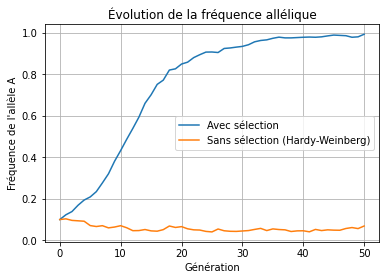

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Simulation
TAILLE_POP = 1000
GENERATIONS = 50

# Fréquence initiale de l'allèle A
freq_A_initiale = 0.1

# Valeurs sélectives (fitness)
# Cas 1 : sélection (ex : antibiotique ou stress)
fitness_selection = {"AA": 1.0,
                     "Aa": 0.9,
                     "aa": 0.7}
# Cas 2 : pas de sélection (équilibre de Hardy-Weinberg)
fitness_neutre = {"AA": 1.0,
                  "Aa": 1.0,
                  "aa": 1.0}

# Génération d'une population
def generer_population(freq_A, taille):
    freq_a = 1 - freq_A
    probabilites = [
        freq_A ** 2,          # AA
        2 * freq_A * freq_a,  # Aa
        freq_a ** 2           # aa
    ]
    return np.random.choice(["AA", "Aa", "aa"], size=taille, p=probabilites)

# Calcul de la fréquence allélique
def calcul_freq_A(population):
    nb_A = sum(genotype.count("A") for genotype in population)
    return nb_A / (2 * len(population))

# Application de la sélection
def appliquer_selection(population, fitness):
    poids = [fitness[g] for g in population]
    total = sum(poids)
    probabilites = [p / total for p in poids]
    return np.random.choice(population, size=len(population), p=probabilites)

# Simulation de l'évolution
def simuler(fitness):
    freq_A = freq_A_initiale
    frequences = [freq_A]  # Initialisation de la liste
    population = generer_population(freq_A, TAILLE_POP)
    for i in range(GENERATIONS):
        population = appliquer_selection(population, fitness)
        freq_A = calcul_freq_A(population)
        population = generer_population(freq_A, TAILLE_POP)
        frequences.append(freq_A)
    return frequences

# Lancement des simulations
freq_selection = simuler(fitness_selection)
freq_neutre = simuler(fitness_neutre)

# Tracé des courbes
plt.figure()
plt.plot(freq_selection, label="Avec sélection")
plt.plot(freq_neutre, label="Sans sélection (Hardy-Weinberg)")
plt.xlabel("Génération")
plt.ylabel("Fréquence de l'allèle A")
plt.title("Évolution de la fréquence allélique")
plt.legend()
plt.grid(True)
plt.show()

Le graphique compare l’évolution de la fréquence de l’allèle A avec et sans sélection naturelle.
Sans sélection (équilibre de Hardy-Weinberg), la fréquence de l’allèle A reste relativement stable au cours des générations. Cela montre qu’en absence de pression de sélection, les fréquences alléliques varient peu
Avec sélection, la fréquence de l’allèle A augmente progressivement au fil des générations. Cela signifie que les individus possédant l’allèle A ont un avantage sélectif et se reproduisent davantage.
Cette simulation montre donc que la sélection naturelle modifie les fréquences alléliques d’une population, contrairement au modèle de Hardy-Weinberg où les fréquences restent stables en absence de forces évolutives.
On peut également observer un effet de dérive génétique lié au hasard des reproductions, surtout si la taille de population diminue.